In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d

import tqdm as tqdm
import time as time


In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 12,                          # Standard font size for scientific papers
    "axes.labelsize": 12,                     # Size of the x and y axis labels
    "xtick.labelsize": 10,                     # Size of the x-tick labels
    "ytick.labelsize": 10,                     # Size of the y-tick labels
    "legend.fontsize": 10,                     # Size of the legend text
    "figure.titlesize": 14                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
### Constants

num_of_gigayears = 0.1
tau_acc = num_of_gigayears*3600*24*365*1e9 # convert to seconds
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e16
m_wdm = 1e16 # in accDM model it should be the same as mass of the DM particle before acceleration, but this implementation is more general and allows to set them independently
omega_dm = 0.1201075
kappa = 12
a_t = 0.13
eta = 0.1

In [4]:
### Run CLASS ###
AccCLASS = {}
# Initialize dictionaries for background and perturbation quantities
bgAcc = {}
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, p_acc, w_acc = {}, {}, {}
rho_nu = {}
rho_tot, rho_crit = {}, {}
z_eq = {}

q_bins_list = [1001, 2001, 5001, 10001, 15001, 20001, 25001, 30001, 35001, 40001]

# Loop over different numbers of momentum bins for the WDM component and run CLASS for each case, record the time taken for each run to see how the performance depends on the number of momentum bins

times = []

for q_bins in tqdm.tqdm(q_bins_list):
    
    print(f'Running CLASS for q_bins = {q_bins}') 
    
    start = time.time()
    AccCLASS = Class()
    AccCLASS.set({
                    ### LCDM params
                    'h': 0.67810,
                    'omega_cdm': omega_dm*(1-f_acc),     # Set the CDM density
                    ### accDM params
                    'vary_Gamma_wdm': 1,                 # Don't vary the decay constant of DCDM, we will set it to a fixed value below
                    'kappa_mon': kappa,                       # 
                    'a_t_mon': a_t,                       # Scale factor at which the acceleration happens
                    'f_wdm': f_acc/(1-f_acc),             # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                    #'omega_ini_dcdm': omega_dm*f_acc,    # Set the density of the WDM component
                    'eta_wdm': eta,                      # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\eta)
                    "tau_wdm": tau_acc,                  # "Lifetime" of the DCDM component, set to a large value to ensure that the acceleration happens late enough
                    "m_wdm_in_GeV": m_wdm,               # accDM mass in GeV
                    "m_cdm_in_GeV": m_dcdm,              # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
                    "N_ncdm": 2,                         # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM in the ncdm sector
                    "deg_ncdm": "3,1",                   # 3 neutrino species and 1 degrees of freedom for the WDM component 
                    "m_ncdm": f"0.02, {m_wdm*1e9}",      # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
                    "T_ncdm": "0.71611, 1",              # Set the same temperature for the WDM component as for the neutrinos, CHECK DEPENDENCE OF THE RESULTS ON THE 2nd ENTRY
                    "ncdm_N_momentum_bins" : f"15, {q_bins}", # Set a higher number of momentum bins for the WDM component, maybe the same number as evolution steps? But that's 40000, so a lot. FOR SIMPSION THE NUBMER OF MOMENTUM BINS SHOULD BE ODD, CHECK THIS
                    "N_ur": 0.00441,                     # Set the number of massless neutrino species to 0 since we are including them as ncdm species
                    "ncdm_quadrature_strategy": "0, 4",  # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)
                    })
    AccCLASS.compute()
    end = time.time()
    
    print(f'Time taken for q_bins = {q_bins}: {end - start:.2f} seconds')
    times.append(end - start)

 10%|█         | 1/10 [00:00<00:05,  1.65it/s]

Running CLASS for q_bins = 1001
Time taken for q_bins = 1001: 0.61 seconds
Running CLASS for q_bins = 2001


 30%|███       | 3/10 [00:07<00:23,  3.29s/it]

Time taken for q_bins = 2001: 1.18 seconds
Running CLASS for q_bins = 5001
Time taken for q_bins = 5001: 6.08 seconds


 50%|█████     | 5/10 [00:24<00:33,  6.73s/it]

...

Time taken for q_bins = 30001: 26.81 seconds
Running CLASS for q_bins = 35001


 90%|█████████ | 9/10 [02:00<00:22, 22.03s/it]

Time taken for q_bins = 35001: 31.73 seconds
Running CLASS for q_bins = 40001


100%|██████████| 10/10 [02:37<00:00, 15.70s/it]

Time taken for q_bins = 40001: 36.60 seconds


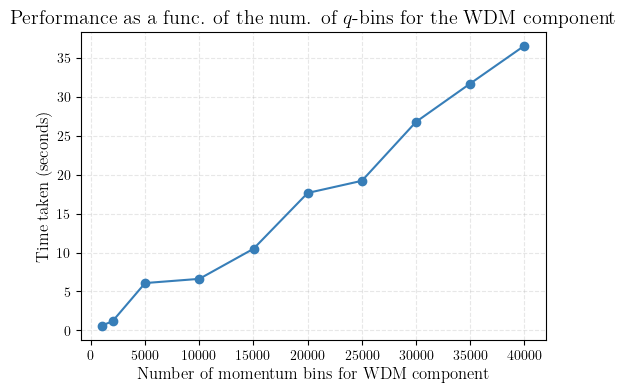

In [5]:
### Plot the time taken as a function of the number of momentum bins

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(q_bins_list, times, marker='o', color=colors_colorblind[0])
ax.set_xscale('linear')
ax.set_xlabel('Number of momentum bins for WDM component')
ax.set_ylabel('Time taken (seconds)')
ax.set_title('Performance as a func. of the num. of $q$-bins for the WDM component')
ax.grid(alpha=0.3, ls='--')
